In [3]:
# импортируем библиотеки, загружаем файл Excel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
Project_final = pd.read_excel('Project.xlsx')

In [45]:
Project_final.head() # проверяем данные по первым строкам

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89
0,NaN,Ключ строки,Период планирования,Ошибки,Предупреждения,Статус обмена,Добавлена,В.,О.,П.,...,ПТС,Документы уведомлений,Номер КЛ,Цена КЛ,Период КЛ,Номер КЛ (Доступно),Период КЛ (Доступно),Кол-во (Плана),Цена плана,Сумма плана
1,NaN,УЛРЗ_000017255_cRRdS51URK6xXr/TbwgFkg==_УЛРЗ/2...,01.10.2025,NaN,NaN,Принят ответ по заявке,Да,Да,Да,Да,...,NaN,00000012671 от 20.11.2025,NaN,NaN,-,NaN,NaN,52,80.88,4205.76
2,NaN,НЛП_000313327_SJUmTuJYSzWt/fbscT59CQ==_Квартал...,01.10.2025,NaN,NaN,Принят ответ по заявке,Да,Да,Да,Да,...,NaN,NaN,NaN,NaN,-,NaN,NaN,100,437.75,43775
3,NaN,УЛРЗ_000005763_I/Yhxk63SZKaEfkQVpZ7CA==_УЛРЗДД...,01.10.2025,NaN,NaN,Сформирована заявка,Да,Нет,Нет,Нет,...,NaN,NaN,NaN,NaN,-,NaN,NaN,200,56.04,11208
4,NaN,РЭРЗ_000095266_FSP5W+2hQNukD66eXwJ8Sw==_Кварта...,01.10.2025,NaN,NaN,Принят ответ по заявке,Да,Да,Да,Да,...,5,NaN,NaN,NaN,-,NaN,NaN,5,22175.9,110879.5


In [47]:
# для удобства переименовываем наименования первых столбцов
Project_final = Project_final.rename(columns={
    'Unnamed: 0': 'Индекс строки',
    'Unnamed: 1': 'Ключ строки',
    'Unnamed: 2': 'Период планирования',
    'Unnamed: 3': 'Ошибки',
    'Unnamed: 4': 'Предупреждения',
    'Unnamed: 5': 'Статус обмена',
    'Unnamed: 6': 'Добавлена',
    'Unnamed: 7': 'В.',
    'Unnamed: 8': 'О.',
    'Unnamed: 9': 'П.',
    'Unnamed: 10': 'К.',
    'Unnamed: 11': 'Дата заявки',
    'Unnamed: 12': 'Номер письма заявки',
    'Unnamed: 13': 'Дата письма заявки',
    'Unnamed: 14': 'Номер письма ответа',
    'Unnamed: 15': 'Дата письма ответа',
    'Unnamed: 16': 'Организация',
    'Unnamed: 17': 'Покупатель',
    'Unnamed: 18': 'Грузоотправитель',
    'Unnamed: 19': 'Грузополучатель',
    'Unnamed: 20': 'Поставщик',
    'Unnamed: 21': 'Поставщик по РВ (Исходный)',
    'Unnamed: 22': 'Поставщик по РВ (Текущий)',
    'Unnamed: 23': 'Изготовитель',
    'Unnamed: 24': 'Изготовитель МЗК',
    'Unnamed: 25': 'ID строки',
    'Unnamed: 26': 'Проект',
    'Unnamed: 27': 'Вид заявки',
    'Unnamed: 28': 'Код заявки',
    'Unnamed: 29': 'Код поставки',
    'Unnamed: 30': 'КодНСИ',
    'Unnamed: 31': 'КодАМТО',
    'Unnamed: 32': 'ЛО',
    'Unnamed: 33': 'Номенклатура',
    'Unnamed: 34': 'Ед. изм.',
    'Unnamed: 35': 'Коэффициент',
    'Unnamed: 36': 'Класс ТМЦ',
    'Unnamed: 37': 'ГОСТ ТУ',
    'Unnamed: 38': 'Сорт размер',
    'Unnamed: 39': 'Чертеж',
    'Unnamed: 40': 'Норма отгрузки',
    'Unnamed: 41': 'Источник закупки заявки',
    'Unnamed: 42': 'Источник закупки',
    'Unnamed: 43': 'Статус источника поставки',
    'Unnamed: 44': 'Дата статуса источника поставки',
    'Unnamed: 45': 'Последнее изменение ИЗ',
    'Unnamed: 46': 'До',
    'Unnamed: 47': '1 месяц',
    'Unnamed: 48': '1 декада',
    'Unnamed: 49': '2 декада',
    'Unnamed: 50': '3 декада',
    'Unnamed: 51': '2 месяц',
    'Unnamed: 52': '1 декада',
    'Unnamed: 53': '2 декада',
    'Unnamed: 54': '3 декада',
    'Unnamed: 55': '3 месяц',
    'Unnamed: 56': '1 декада',
    'Unnamed: 57': '2 декада',
    'Unnamed: 58': '3 декада',
    'Unnamed: 59': 'После',
    'Unnamed: 60': 'Количество для снятия',
    'Unnamed: 61': 'Статус снятия',
    'Unnamed: 62': 'Статус (ответ поставщика)',
    'Unnamed: 63': 'Комментарий ДС',
    'Unnamed: 64': 'Комментарий ДП',
    'Unnamed: 65': 'Комментарий ДКП',
    'Unnamed: 66': 'Комментарий "Филиал"',
    'Unnamed: 67': 'Статус ответа "Филиал"',
    'Unnamed: 68': 'Дата ответа "Филиал"',
    'Unnamed: 69': 'с поставщиком',
    'Unnamed: 70': 'в ЗнТ',
    'Unnamed: 71': 'в ПТУ',
    'Unnamed: 72': 'Уведомление',
    'Unnamed: 73': 'Документы ЗП',
    'Unnamed: 74': 'Дата отгрузки',
    'Unnamed: 75': 'Номер спецификации',
    'Unnamed: 76': 'Дата спецификации',
    'Unnamed: 77': 'Документы УПД',
    'Unnamed: 78': 'Документы ЗНТ',
    'Unnamed: 79': 'Документы ПТС',
    'Unnamed: 80': 'ПТС',
    'Unnamed: 81': 'Документы уведомлений',
    'Unnamed: 82': 'Номер КЛ',
    'Unnamed: 83': 'Цена КЛ',
    'Unnamed: 84': 'Период КЛ',
    'Unnamed: 85': 'Номер КЛ (Доступно)',
    'Unnamed: 86': 'Период КЛ (Доступно)',
    'Unnamed: 87': 'Кол-во (Плана)',
    'Unnamed: 88': 'Цена плана',
    'Unnamed: 89': 'Сумма плана'
})

In [49]:
# посмотрим на типы данных, пропущенные значения, обновленные наименования столбцов после переименования
Project_final.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25685 entries, 0 to 25684
Data columns (total 90 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Индекс строки                    0 non-null      float64
 1   Ключ строки                      25684 non-null  object 
 2   Период планирования              25684 non-null  object 
 3   Ошибки                           1 non-null      object 
 4   Предупреждения                   25631 non-null  object 
 5   Статус обмена                    19350 non-null  object 
 6   Добавлена                        25684 non-null  object 
 7   В.                               25684 non-null  object 
 8   О.                               25684 non-null  object 
 9   П.                               25684 non-null  object 
 10  К.                               25684 non-null  object 
 11  Дата заявки                      25684 non-null  object 
 12  Номер письма заявк

In [8]:
# еще раз проверяем данные по первым строкам, чтобы убедиться, что переименованные столбцы соответствуют данным
Project_final.head()

,Индекс строки,Ключ строки,Период планирования,Ошибки,Предупреждения,Статус обмена,Добавлена,В.,О.,П.,...,ПТС,Документы уведомлений,Номер КЛ,Цена КЛ,Период КЛ,Номер КЛ (Доступно),Период КЛ (Доступно),Кол-во (Плана),Цена плана,Сумма плана
0,NaN,Ключ строки,Период планирования,Ошибки,Предупреждения,Статус обмена,Добавлена,В.,О.,П.,...,ПТС,Документы уведомлений,Номер КЛ,Цена КЛ,Период КЛ,Номер КЛ (Доступно),Период КЛ (Доступно),Кол-во (Плана),Цена плана,Сумма плана
1,NaN,УЛРЗ_000017255_cRRdS51URK6xXr/TbwgFkg==_УЛРЗ/2...,01.10.2025,NaN,NaN,Принят ответ по заявке,Да,Да,Да,Да,...,NaN,00000012671 от 20.11.2025,NaN,NaN,-,NaN,NaN,52,80.88,4205.76
2,NaN,НЛП_000313327_SJUmTuJYSzWt/fbscT59CQ==_Квартал...,01.10.2025,NaN,NaN,Принят ответ по заявке,Да,Да,Да,Да,...,NaN,NaN,NaN,NaN,-,NaN,NaN,100,437.75,43775
3,NaN,УЛРЗ_000005763_I/Yhxk63SZKaEfkQVpZ7CA==_УЛРЗДД...,01.10.2025,NaN,NaN,Сформирована заявка,Да,Нет,Нет,Нет,...,NaN,NaN,NaN,NaN,-,NaN,NaN,200,56.04,11208
4,NaN,РЭРЗ_000095266_FSP5W+2hQNukD66eXwJ8Sw==_Кварта...,01.10.2025,NaN,NaN,Принят ответ по заявке,Да,Да,Да,Да,...,5,NaN,NaN,NaN,-,NaN,NaN,5,22175.9,110879.5


In [51]:
# для нашего будущего дашборда не требуются все столбцы, поэтому определяем лишние
columns_to_drop = [
    'Индекс строки','Ключ строки', 'Ошибки', 'Грузополучатель','Предупреждения', 'Период планирования','Статус обмена', 'Добавлена', 
    'В.', 'О.', 'П.', 'К.', 'Дата заявки', 'Номер письма заявки', 
    'Дата письма заявки', 'Номер письма ответа', 'Дата письма ответа', 
    'Покупатель', 'Грузоотправитель', 'Поставщик по РВ (Исходный)', 
    'Поставщик по РВ (Текущий)', 'Изготовитель', 'Изготовитель МЗК', 'ID строки', 'Вид заявки',
    'Код заявки', 'Код поставки', 'КодНСИ', 'КодАМТО', 'с поставщиком', 'Дата отгрузки',
    'Проект', 'Коэффициент', 'Класс ТМЦ', 'ГОСТ ТУ', 'Сорт размер', 
    'Чертеж', 'Норма отгрузки', 'Источник закупки заявки', 
    'Статус источника поставки', 'Дата статуса источника поставки', 
    'Последнее изменение ИЗ', 'До', '1 декада', '2 декада', '3 декада', 
    'После', 'Количество для снятия', 'Статус снятия', 'Комментарий ДС', 
    'Комментарий ДП', 'Комментарий ДКП', 'Комментарий "Филиал"', 
    'Статус ответа "Филиал"', 'Дата ответа "Филиал"', 'в ЗнТ', 'в ПТУ', 
    'Уведомление', 'Документы ЗП', 'Номер спецификации', 'Дата спецификации', 
    'Документы УПД', 'Документы ЗНТ', 'Документы ПТС', 'ПТС', 
    'Документы уведомлений', 'Номер КЛ', 'Цена КЛ', 'Период КЛ', 
    'Номер КЛ (Доступно)', 'Период КЛ (Доступно)'
]

In [53]:
# удаляем лишние столбцы
Project_final = Project_final.drop(columns=columns_to_drop, errors='ignore')

In [55]:
# проверяем, что столбцы удалились и остались только нужные
# один из ключевых столбцов на нашем дашборде - это статус(ответ поставщика), не должно быть пустых значений. Видим, что всего заполнено 17770 строк, остальное необходимо удалить 
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25685 entries, 0 to 25684
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                25684 non-null  object
 1   Поставщик                  23986 non-null  object
 2   ЛО                         25684 non-null  object
 3   Номенклатура               25684 non-null  object
 4   Ед. изм.                   25673 non-null  object
 5   Источник закупки           25684 non-null  object
 6   1 месяц                    7386 non-null   object
 7   2 месяц                    11678 non-null  object
 8   3 месяц                    12592 non-null  object
 9   Статус (ответ поставщика)  17770 non-null  object
 10  Кол-во (Плана)             22418 non-null  object
 11  Цена плана                 25684 non-null  object
 12  Сумма плана                22419 non-null  object
dtypes: object(13)
memory usage: 2.5+ MB


In [59]:
# проверяем количестово пропущенных значений в столбце Статус (ответ поставщика)
print(Project_final['Статус (ответ поставщика)'].value_counts(dropna=False))

Статус (ответ поставщика)
Принято к поставке                                                              11992
NaN                                                                              7915
Не принято. Отсутствие коммерческих предложений от потенциальных поставщиков     1773
Не принято. Не отгрузочная норма                                                 1373
Снято полностью                                                                   911
Не принято. Несоответствие распределительной ведомости                            477
Не принято. Загруженность производства                                            231
Не принято. Снято с производства                                                  184
Не принято. Требуется согласование допустимой замены                              181
Принято частично                                                                  140
Не принято. Импорт, поставки в РФ не осуществляются                               118
Не принято. Некорректный гру

In [61]:
# удаляем пропущенные значения в столбце Статус (ответ поставщика)
Project_final.dropna(subset=['Статус (ответ поставщика)'], inplace=True)

In [63]:
# проверяем данные после удаления 
# Далее отмечаем по пропускам, что сумма плана заполнена не по всем строкам. Это также один из ключевых показателй, поэтому необходимо удалить строки с пустыми значениями
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17770 entries, 0 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                17770 non-null  object
 1   Поставщик                  17728 non-null  object
 2   ЛО                         17770 non-null  object
 3   Номенклатура               17770 non-null  object
 4   Ед. изм.                   17759 non-null  object
 5   Источник закупки           17770 non-null  object
 6   1 месяц                    4635 non-null   object
 7   2 месяц                    6449 non-null   object
 8   3 месяц                    9714 non-null   object
 9   Статус (ответ поставщика)  17770 non-null  object
 10  Кол-во (Плана)             15658 non-null  object
 11  Цена плана                 17770 non-null  object
 12  Сумма плана                15658 non-null  object
dtypes: object(13)
memory usage: 1.9+ MB


In [65]:
# удаляем пустые строки из столбца Сумма плана
Project_final.dropna(subset=['Сумма плана'], inplace=True)

In [67]:
# проверям данные после удаления
# следующий ключевой показатель - Поставщик, видим, что не все строки заполнены, необходимо удалить пустые значения
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15658 entries, 0 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15658 non-null  object
 1   Поставщик                  15657 non-null  object
 2   ЛО                         15658 non-null  object
 3   Номенклатура               15658 non-null  object
 4   Ед. изм.                   15647 non-null  object
 5   Источник закупки           15658 non-null  object
 6   1 месяц                    4635 non-null   object
 7   2 месяц                    6449 non-null   object
 8   3 месяц                    9714 non-null   object
 9   Статус (ответ поставщика)  15658 non-null  object
 10  Кол-во (Плана)             15658 non-null  object
 11  Цена плана                 15658 non-null  object
 12  Сумма плана                15658 non-null  object
dtypes: object(13)
memory usage: 1.7+ MB


In [71]:
# удаляем пустые строки из столбца Поставщик
Project_final.dropna(subset=['Поставщик'], inplace=True)

In [73]:
# проверям данные после удаления
# видим, что есть пустные сроки по столбцу Ед.изм, однако это не критично, оставляем как есть
# Также оставляем как есть данные по 1 месяцу, 2 месяцу и 3  месяцу, так как Кол-во (плана) распределяется по месяцам.
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15657 entries, 0 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15657 non-null  object
 1   Поставщик                  15657 non-null  object
 2   ЛО                         15657 non-null  object
 3   Номенклатура               15657 non-null  object
 4   Ед. изм.                   15646 non-null  object
 5   Источник закупки           15657 non-null  object
 6   1 месяц                    4634 non-null   object
 7   2 месяц                    6448 non-null   object
 8   3 месяц                    9713 non-null   object
 9   Статус (ответ поставщика)  15657 non-null  object
 10  Кол-во (Плана)             15657 non-null  object
 11  Цена плана                 15657 non-null  object
 12  Сумма плана                15657 non-null  object
dtypes: object(13)
memory usage: 1.7+ MB


In [69]:
# проверяем, чтобы убедиться, что данные в столбцах представлены верно
Project_final.head()

,Организация,Поставщик,ЛО,Номенклатура,Ед. изм.,Источник закупки,1 месяц,2 месяц,3 месяц,Статус (ответ поставщика),Кол-во (Плана),Цена плана,Сумма плана
0,Организация,Поставщик,ЛО,Номенклатура,Ед. изм.,Источник закупки,1 месяц,2 месяц,3 месяц,Статус (ответ поставщика),Кол-во (Плана),Цена плана,Сумма плана
1,"Уссурийский ЛРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Циферблат МП У3 0-1,6 МПа, кл.т. 1,5",шт,ЦЗ,NaN,NaN,52,Принято к поставке,52,80.88,4205.76
2,"Новосибирское литейное производство АО ""Желдор...","Торговый дом ТМХ, АО",Нет,Очки защитные открытого типа ЖДРМ309 с боковой...,шт,ЦЗ,NaN,NaN,100,Принято к поставке,100,437.75,43775
4,"Ростовский-на-Дону ЭРЗ - филиал АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Да,"Реактор Р-72, черт. ДТЖИ.671331.004 (6ТН.210.0...",шт,ЦЗ,NaN,NaN,5,Принято к поставке,5,22175.9,110879.5
5,"Уссурийский ЛРЗ АО ""Желдорреммаш""","СТАНКОРЕМСЕРВИС, ООО",Нет,Плашка Зубр Мастер арт.4-28022-39-2 М39х2,шт,ЦЗ - Филиал,NaN,NaN,1,Принято к поставке,1,1186.08,1186.08


In [77]:
# теперь нам необходимо привести количественные переменные к правильному типу данных - float64 или int
columns_to_convert = ['1 месяц', '2 месяц', '3 месяц', 'Кол-во (Плана)', 'Цена плана', 'Сумма плана']
for col in columns_to_convert:
    Project_final[col] = pd.to_numeric(Project_final[col], errors='coerce')

In [79]:
# проверяем данные после преобразования
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15657 entries, 0 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Организация                15657 non-null  object 
 1   Поставщик                  15657 non-null  object 
 2   ЛО                         15657 non-null  object 
 3   Номенклатура               15657 non-null  object 
 4   Ед. изм.                   15646 non-null  object 
 5   Источник закупки           15657 non-null  object 
 6   1 месяц                    4633 non-null   float64
 7   2 месяц                    6447 non-null   float64
 8   3 месяц                    9712 non-null   float64
 9   Статус (ответ поставщика)  15657 non-null  object 
 10  Кол-во (Плана)             15656 non-null  float64
 11  Цена плана                 15656 non-null  float64
 12  Сумма плана                15652 non-null  float64
dtypes: float64(6), object(7)
memory usage: 1.7+ MB


In [81]:
# с целью округления данных принимаем решение о преобразовании данных в int
int_columns = ['1 месяц', '2 месяц', '3 месяц', 'Кол-во (Плана)', 'Цена плана', 'Сумма плана']
for col in int_columns:
    Project_final[col] = Project_final[col].round().astype('Int64')

In [83]:
# проверяем данные после преобразования
# видим, что данные в столбце Сумма плана сократились, поэтому удалим пустые значения в данном столбце
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15657 entries, 0 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15657 non-null  object
 1   Поставщик                  15657 non-null  object
 2   ЛО                         15657 non-null  object
 3   Номенклатура               15657 non-null  object
 4   Ед. изм.                   15646 non-null  object
 5   Источник закупки           15657 non-null  object
 6   1 месяц                    4633 non-null   Int64 
 7   2 месяц                    6447 non-null   Int64 
 8   3 месяц                    9712 non-null   Int64 
 9   Статус (ответ поставщика)  15657 non-null  object
 10  Кол-во (Плана)             15656 non-null  Int64 
 11  Цена плана                 15656 non-null  Int64 
 12  Сумма плана                15652 non-null  Int64 
dtypes: Int64(6), object(7)
memory usage: 1.8+ MB


In [91]:
# удаляем пустые строки из столбца Сумма плана
Project_final.dropna(subset=['Сумма плана'], inplace=True)

In [93]:
# проверяем данные после удаления
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15652 entries, 1 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15652 non-null  object
 1   Поставщик                  15652 non-null  object
 2   ЛО                         15652 non-null  object
 3   Номенклатура               15652 non-null  object
 4   Ед. изм.                   15641 non-null  object
 5   Источник закупки           15652 non-null  object
 6   1 месяц                    4631 non-null   Int64 
 7   2 месяц                    6446 non-null   Int64 
 8   3 месяц                    9710 non-null   Int64 
 9   Статус (ответ поставщика)  15652 non-null  object
 10  Кол-во (Плана)             15652 non-null  Int64 
 11  Цена плана                 15652 non-null  Int64 
 12  Сумма плана                15652 non-null  Int64 
dtypes: Int64(6), object(7)
memory usage: 1.8+ MB


In [133]:
# проверяем на дубликаты
Project_final.duplicated().sum()

81

In [137]:
# удаляем дубликаты
Project_final.drop_duplicates()

,Организация,Поставщик,ЛО,Номенклатура,Ед. изм.,Источник закупки,1 месяц,2 месяц,3 месяц,Статус (ответ поставщика),Кол-во (Плана),Цена плана,Сумма плана
1,"Уссурийский ЛРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Циферблат МП У3 0-1,6 МПа, кл.т. 1,5",шт,ЦЗ,<NA>,<NA>,52,Принято к поставке,52,81,4206
2,"Новосибирское литейное производство АО ""Желдор...","Торговый дом ТМХ, АО",Нет,Очки защитные открытого типа ЖДРМ309 с боковой...,шт,ЦЗ,<NA>,<NA>,100,Принято к поставке,100,438,43775
4,"Ростовский-на-Дону ЭРЗ - филиал АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Да,"Реактор Р-72, черт. ДТЖИ.671331.004 (6ТН.210.0...",шт,ЦЗ,<NA>,<NA>,5,Принято к поставке,5,22176,110880
5,"Уссурийский ЛРЗ АО ""Желдорреммаш""","СТАНКОРЕМСЕРВИС, ООО",Нет,Плашка Зубр Мастер арт.4-28022-39-2 М39х2,шт,ЦЗ - Филиал,<NA>,<NA>,1,Принято к поставке,1,1186,1186
8,"Ярославский ЭРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Крышка клапана ТУ 3184-008-05744521-98, черт. ...",шт,ЦЗ,<NA>,3,<NA>,Принято к поставке,3,4786,14359
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25674,"Улан-Удэнский ЛВРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,Пускатель электромагнитный ПМЛ-4620 63А 380В U...,шт,ЦЗ,<NA>,25,<NA>,Принято к поставке,25,8124,203106
25676,"Улан-Удэнский ЛВРЗ АО ""Желдорреммаш""","ПриборКомплект, ООО",Нет,Рукав III-9-2 ГОСТ 9356-75,м,ЦЗ - Филиал,100,<NA>,<NA>,Принято к поставке,100,48,4758
25681,Астраханский тепловозоремонтный завод,"СТАНКОРЕМСЕРВИС, ООО",Нет,Пресс гидравлический WiederKraft WDK-HP121 12 т,шт,ЦЗ - Филиал,<NA>,<NA>,1,Принято к поставке,1,26489,26489
25682,"Ростовский-на-Дону ЭРЗ - филиал АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,Оповещатель охранно-пожарный световой ОПОП 15-...,шт,ЦЗ,12,12,11,Принято к поставке,35,889,31108


In [141]:
# еще раз проверка данных
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15651 entries, 1 to 25683
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15651 non-null  object
 1   Поставщик                  15651 non-null  object
 2   ЛО                         15651 non-null  object
 3   Номенклатура               15651 non-null  object
 4   Ед. изм.                   15640 non-null  object
 5   Источник закупки           15651 non-null  object
 6   1 месяц                    4631 non-null   Int64 
 7   2 месяц                    6445 non-null   Int64 
 8   3 месяц                    9710 non-null   Int64 
 9   Статус (ответ поставщика)  15651 non-null  object
 10  Кол-во (Плана)             15651 non-null  Int64 
 11  Цена плана                 15651 non-null  Int64 
 12  Сумма плана                15651 non-null  Int64 
dtypes: Int64(6), object(7)
memory usage: 1.8+ MB


In [143]:
# посчитаем основные описательные статистики для числовых столбцов
# из результатов мы видим, что значения сильно разбросаны по суммам (от 0,0 руб. до 70 млн. за единицу товара(Цена плана)), с точки зрения закупки это значит, что производились закупки от болтов до очень дорогого оборудования, мы не будем удалять лишнее и считать за выбросы, все закупки нам нужны.
# при первом запуске кода в min были отрицательные значения, необходимо их удалить, это ошибка учета данных
Project_final.describe()

,1 месяц,2 месяц,3 месяц,Кол-во (Плана),Цена плана,Сумма плана
count,4631.0,6445.0,9710.0,15651.0,15651.0,15651.0
mean,6211.518463,3964.096974,1315.870855,4293.791451,52977.451984,501369.089771
std,160289.420641,94094.509904,11874.38158,106618.685306,1224954.626506,5354607.831722
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,4.0,6.0,5.0,8.0,89.0,5331.5
50%,21.0,37.0,22.0,40.0,570.0,28747.0
75%,160.0,250.0,150.0,252.0,3985.5,148764.0
max,8750000.0,6365000.0,477414.0,8750000.0,70071995.0,514299888.0


In [145]:
# удаляем строки с отрицательными значениями 
Project_final = Project_final[(Project_final[int_columns] >= 0).all(axis=1)]

In [147]:
# проверяем описательные статистики для числовых столбцов
Project_final.describe()

,1 месяц,2 месяц,3 месяц,Кол-во (Плана),Цена плана,Сумма плана
count,4631.0,6445.0,9710.0,15651.0,15651.0,15651.0
mean,6211.518463,3964.096974,1315.870855,4293.791451,52977.451984,501369.089771
std,160289.420641,94094.509904,11874.38158,106618.685306,1224954.626506,5354607.831722
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,4.0,6.0,5.0,8.0,89.0,5331.5
50%,21.0,37.0,22.0,40.0,570.0,28747.0
75%,160.0,250.0,150.0,252.0,3985.5,148764.0
max,8750000.0,6365000.0,477414.0,8750000.0,70071995.0,514299888.0


In [149]:
# для возможности построения графиков импортируем библиотеку Seaborn
import seaborn as sns

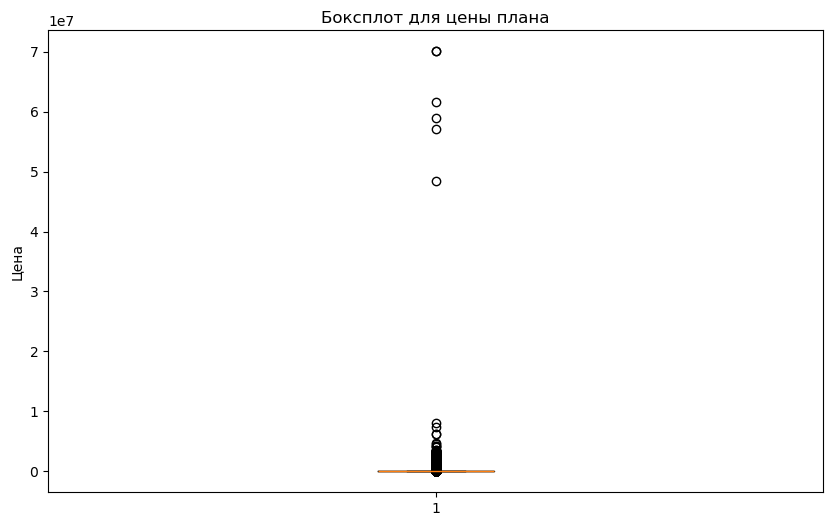

In [151]:
# строим боксплот для цены плана
# в результате видим, что цены плана в основной своей массе распределены от 0 до 10 млн. руб.
plt.figure(figsize=(10, 6))
plt.boxplot(Project_final['Цена плана'].dropna())
plt.title('Боксплот для цены плана')
plt.ylabel('Цена')
plt.show()

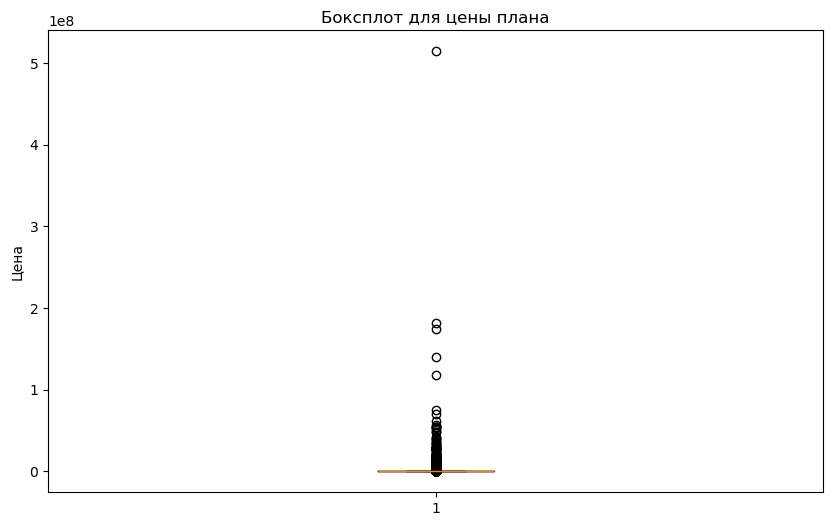

In [153]:
# строим боксплот для суммы плана
# в результате видим, что цены плана в основной своей массе распределены от 0 до 100 млн. руб.
plt.figure(figsize=(10, 6))
plt.boxplot(Project_final['Сумма плана'].dropna())
plt.title('Боксплот для цены плана')
plt.ylabel('Цена')
plt.show()

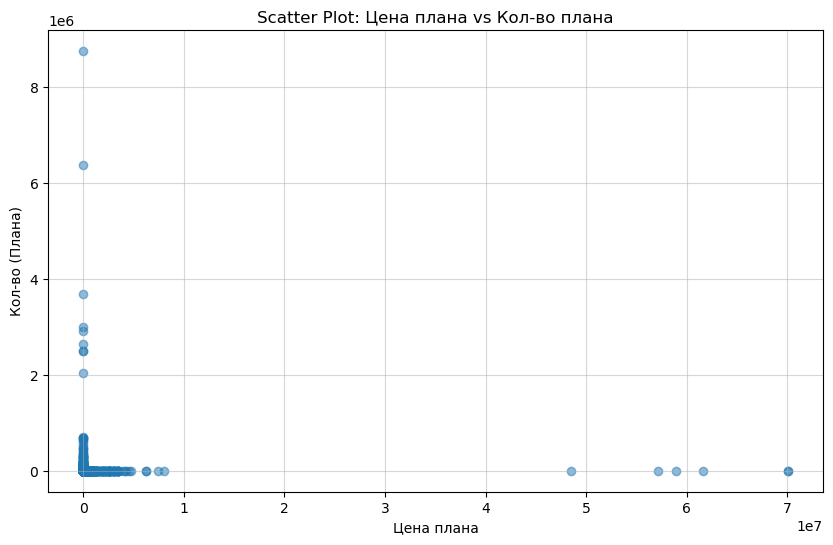

In [155]:
# строим scatter plot для выявления взаимосвязи между Ценой плана и количеством закупаемой продукции (Кол-во (Плана))
plt.figure(figsize=(10, 6))
plt.scatter(Project_final['Цена плана'], Project_final['Кол-во (Плана)'], alpha=0.5)
plt.xlabel('Цена плана')
plt.ylabel('Кол-во (Плана)')
plt.title('Scatter Plot: Цена плана vs Кол-во плана')
plt.grid(True, alpha=0.5)
plt.show()

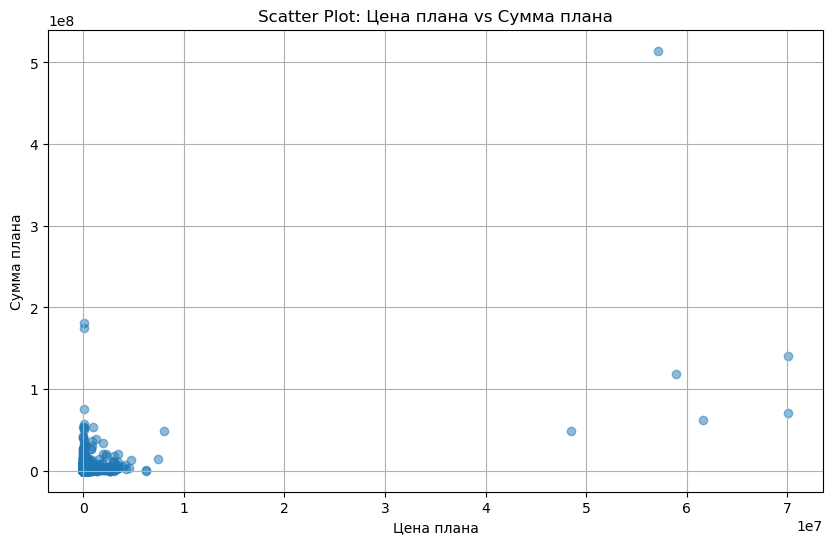

In [157]:
# также строим scatter plot для выявления взаимосвязи между Ценой плана и Суммой плана
plt.figure(figsize=(10, 6))
plt.scatter(Project_final['Цена плана'], Project_final['Сумма плана'], alpha=0.5)
plt.xlabel('Цена плана')
plt.ylabel('Сумма плана')
plt.title('Scatter Plot: Цена плана vs Сумма плана')
plt.grid(True, alpha=1)
plt.show()

In [159]:
# посчитаем статистики для категориальных переменных 
# из результата видим, что наибольшее количество позиций закупались Ростовским-на-Дону ЭРЗ, поставщик  - Торговый дом ТМХ  и т.д.
Project_final.describe(include='object')

,Организация,Поставщик,ЛО,Номенклатура,Ед. изм.,Источник закупки,Статус (ответ поставщика)
count,15651,15651,15651,15651,15640,15651,15651
unique,19,218,2,10596,21,5,17
top,"Ростовский-на-Дону ЭРЗ - филиал АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,Смазка пластичная Буксол ТУ 0254-107-01124328-01,шт,ЦЗ,Принято к поставке
freq,2779,9677,15609,16,11692,10169,11715


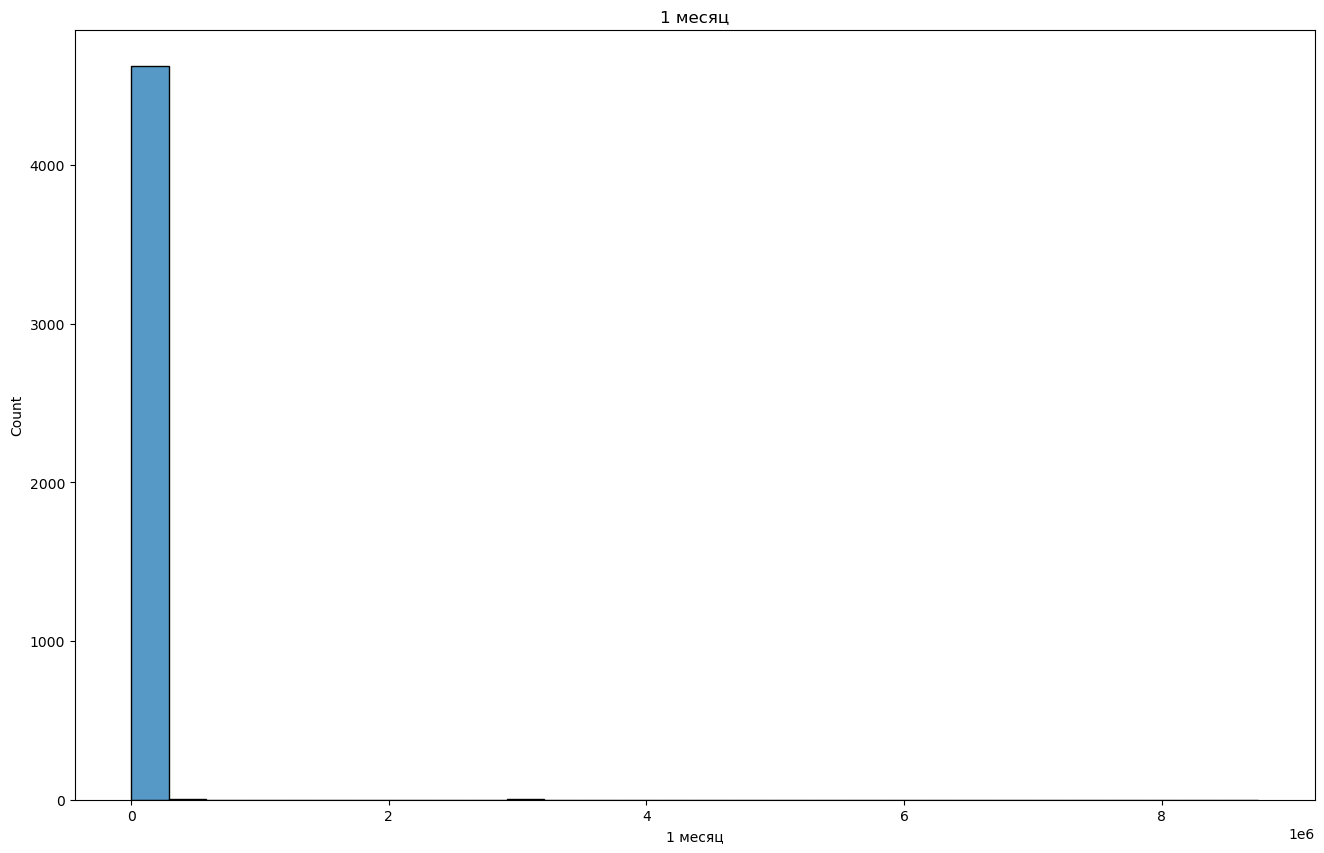

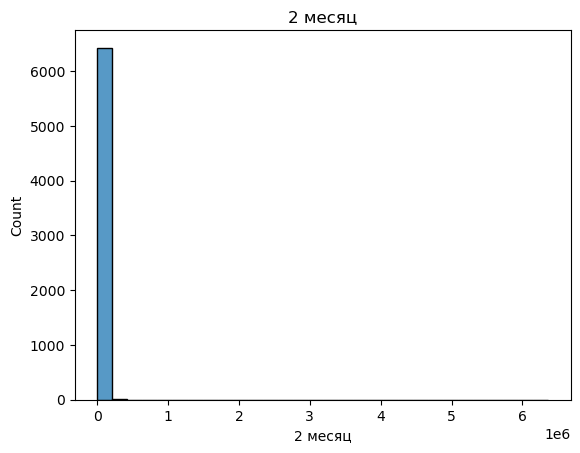

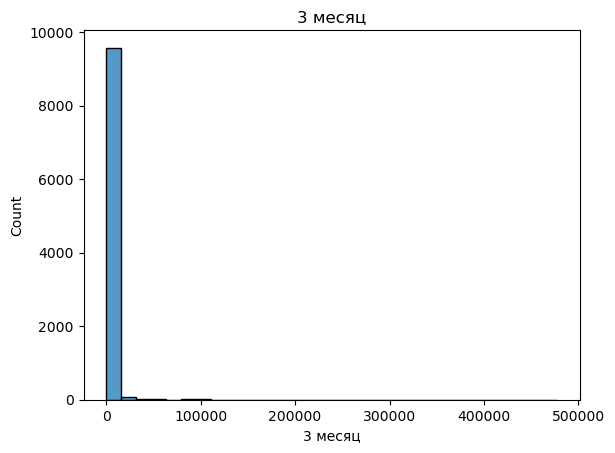

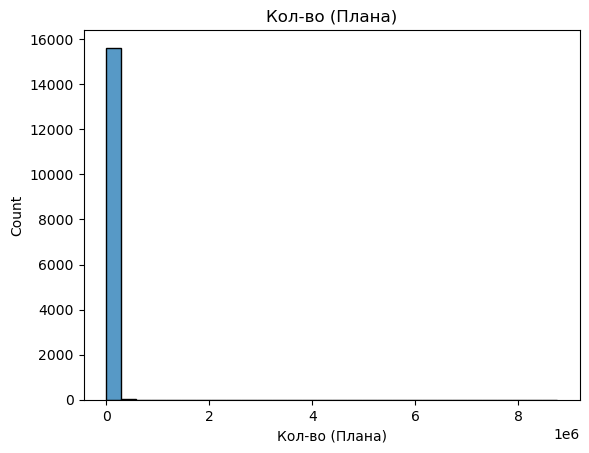

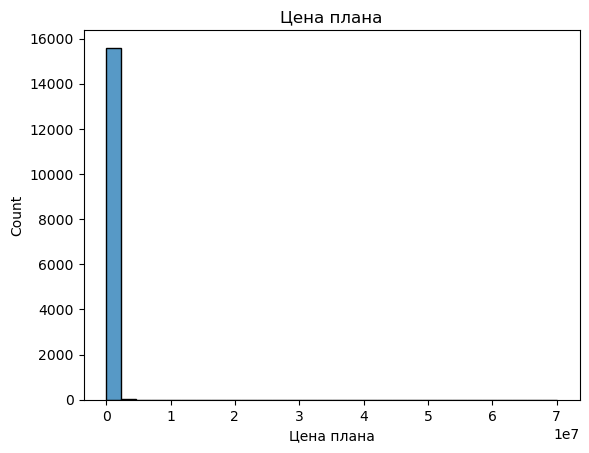

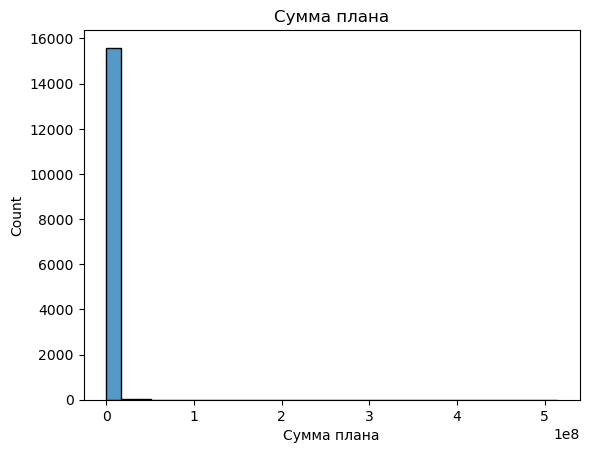

In [121]:
# смотрим гистограммы распределения для каждого столбца с количественными переменными
# в результате видим, что наибольшее кол-во номенклатуры закупалось в 3-м месяце 
plt.figure(figsize=(16, 10))

for var in int_columns:
    sns.histplot(Project_final[var], bins=30)
    plt.title(var)
    plt.show()

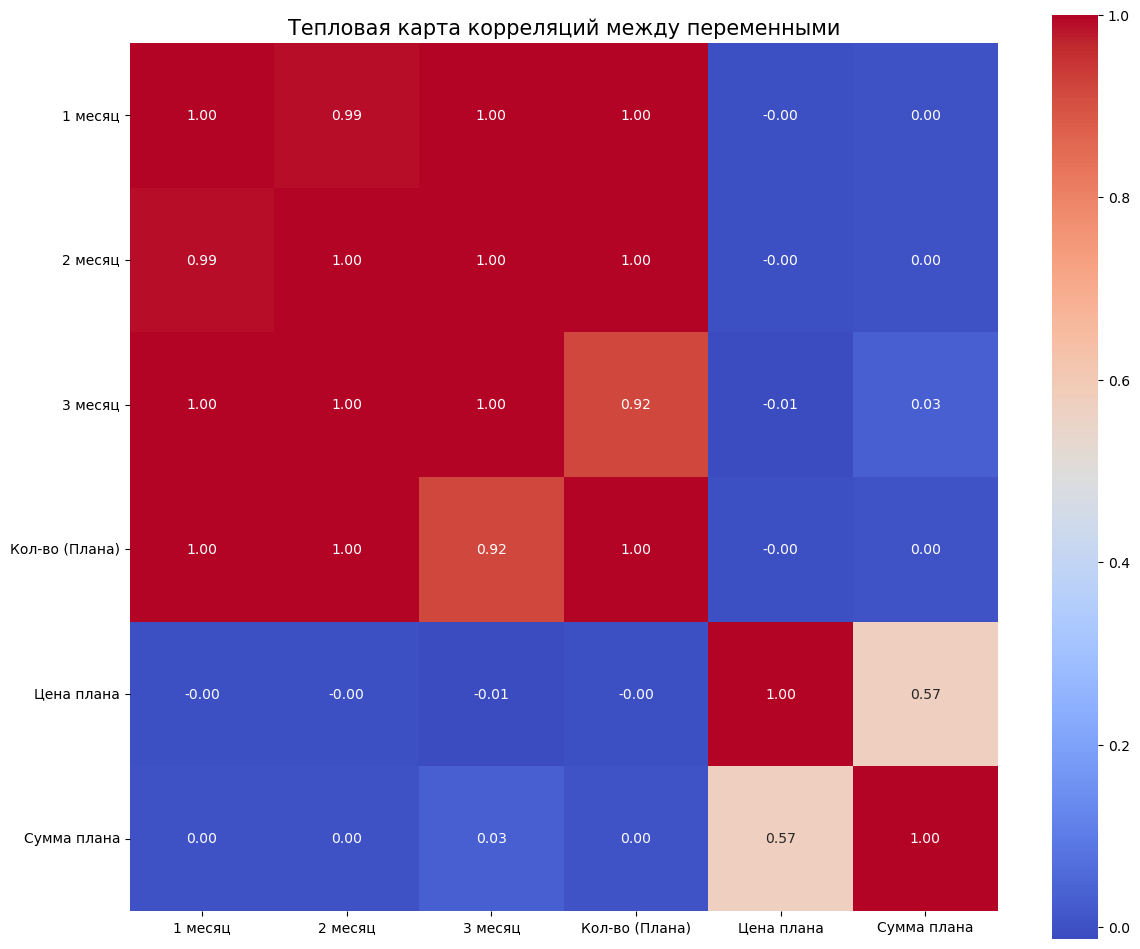

In [161]:
# строим тепловую матрицу количественных переменных
# основные выводы, которые можно сделать: 1. кол-во плана жестко привязано к первым двум месяцам и чуть слабее к третъему (скорее всего кол-во ТМЦ четко планируется в первые 2 месяца)
# 2. цена плана никак не коррелирует с кол-ом плана и месяцами, не зависима от этих показателей, но имеет корреляцию с ценой плана, что понятно
# общий вывод -закупки не зависят от цены (скорее всего зависят от других факторов)
correlation_matrix = Project_final[int_columns].corr(numeric_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Тепловая карта корреляций между переменными', fontsize=15)
plt.yticks(rotation=0)
plt.show()

In [163]:
# создаем новый объект данных для последующих вычислений
df_num = Project_final[int_columns]

In [165]:
# выводим матрицу корреляции Пирсона для сравнения с тепловой картой корреляций
correlation_matrix = df_num.corr()
print("Матрица корреляций Пирсона:")
print(correlation_matrix)


Матрица корреляций Пирсона:
                 1 месяц   2 месяц   3 месяц  Кол-во (Плана)  Цена плана  \
1 месяц         1.000000  0.989874  0.999890        0.998599   -0.002135   
2 месяц         0.989874  1.000000  0.999884        0.997041   -0.001707   
3 месяц         0.999890  0.999884  1.000000        0.918946   -0.013023   
Кол-во (Плана)  0.998599  0.997041  0.918946        1.000000   -0.001738   
Цена плана     -0.002135 -0.001707 -0.013023       -0.001738    1.000000   
Сумма плана     0.000855  0.002239  0.031868        0.003812    0.574392   

                Сумма плана  
1 месяц            0.000855  
2 месяц            0.002239  
3 месяц            0.031868  
Кол-во (Плана)     0.003812  
Цена плана         0.574392  
Сумма плана        1.000000  


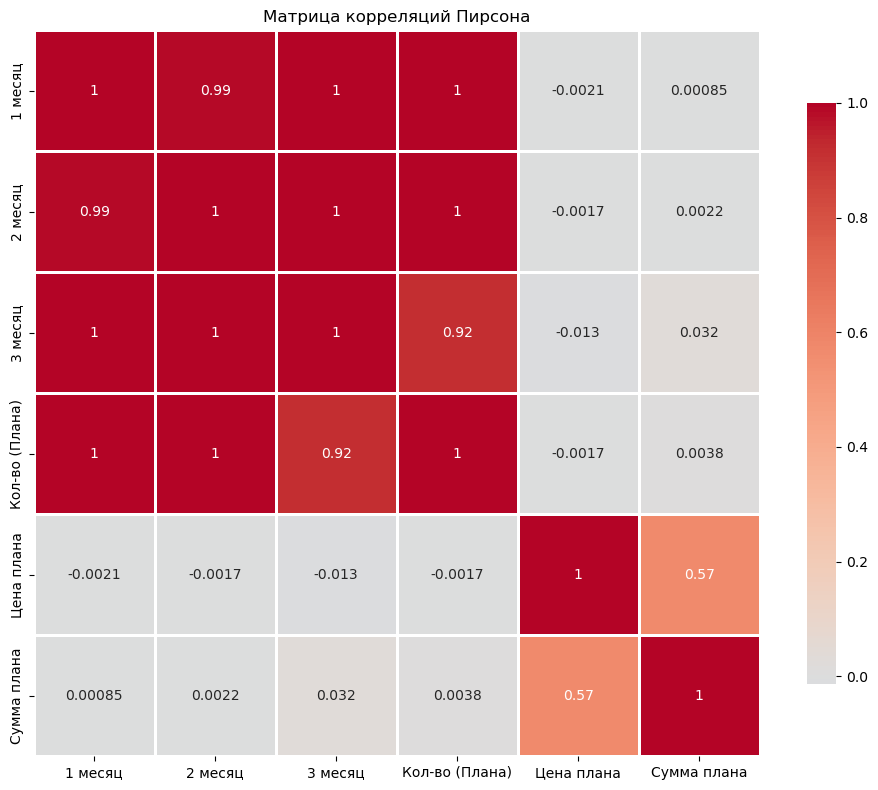

In [167]:
# строим матрицу корреляции Пирсона, отмечает, что данные с тепловой картой сходятся
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций Пирсона')
plt.tight_layout()
plt.show()

In [169]:
# для будущего дашборда нам понадобятся суммы закупки по каждому месяцу, рассчитываем по формуле
Project_final['1 месяц_сумма'] = Project_final['1 месяц'] * Project_final['Цена плана']
Project_final['2 месяц_сумма'] = Project_final['2 месяц'] * Project_final['Цена плана']
Project_final['3 месяц_сумма'] = Project_final['3 месяц'] * Project_final['Цена плана']

In [173]:
# смотрит получившиеся данные, проверяем
print(Project_final[['1 месяц', '2 месяц', '3 месяц', '1 месяц_сумма', '2 месяц_сумма', '3 месяц_сумма', 'Цена плана']].head())

   1 месяц  2 месяц  3 месяц  1 месяц_сумма  2 месяц_сумма  3 месяц_сумма  \
1     <NA>     <NA>       52           <NA>           <NA>           4212   
2     <NA>     <NA>      100           <NA>           <NA>          43800   
4     <NA>     <NA>        5           <NA>           <NA>         110880   
5     <NA>     <NA>        1           <NA>           <NA>           1186   
8     <NA>        3     <NA>           <NA>          14358           <NA>   

   Цена плана  
1          81  
2         438  
4       22176  
5        1186  
8        4786  


In [171]:
# проверяем наличие новых столбцов в датасете
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15651 entries, 1 to 25683
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15651 non-null  object
 1   Поставщик                  15651 non-null  object
 2   ЛО                         15651 non-null  object
 3   Номенклатура               15651 non-null  object
 4   Ед. изм.                   15640 non-null  object
 5   Источник закупки           15651 non-null  object
 6   1 месяц                    4631 non-null   Int64 
 7   2 месяц                    6445 non-null   Int64 
 8   3 месяц                    9710 non-null   Int64 
 9   Статус (ответ поставщика)  15651 non-null  object
 10  Кол-во (Плана)             15651 non-null  Int64 
 11  Цена плана                 15651 non-null  Int64 
 12  Сумма плана                15651 non-null  Int64 
 13  1 месяц_сумма              4631 non-null   Int64 
 14  2 месяц_сум

In [175]:
# теперь нам необходимо создать новый столбец, объединить филиалы, которые относятся к одному региону, еще раз смотрим на все филиалы
print(Project_final['Организация'].value_counts(dropna=False))

Организация
Ростовский-на-Дону ЭРЗ - филиал АО "Желдорреммаш"     2779
Улан-Удэнский ЛВРЗ АО "Желдорреммаш"                  2329
Уссурийский ЛРЗ АО "Желдорреммаш"                     2012
Астраханский тепловозоремонтный завод                 1992
Ярославский ЭРЗ АО "Желдорреммаш"                     1906
Воронежский ТРЗ АО "Желдорреммаш"                     1417
Оренбургский локомотиворемонтный завод                1347
Челябинский ЭРЗ АО "Желдорреммаш"                     1057
ОП "Элмашремонт-Улан-Удэ" "ЛокоТех-ЭМД"                349
ОП "Элмашремонт-Ростов" "ЛокоТех-ЭМД"                  268
Новосибирское литейное производство АО "Желдорремм      63
ОП "Элмашсервис-Канск-Иланский" "ЛокоТех-ЭМД"           36
ОП"Оренбургский дизельремонтный завод""ЛокоТех-ДД"      34
ОП"Астраханский дизельремонтный завод""ЛокоТех-ДД"      28
ОП"Уссурийский дизельремонтный завод""ЛокоТех-ДД"       26
ОП "Элмашремонт-Ярославль" "ЛокоТех-ЭМД"                 3
ОП "Элмашремонт-Челябинск" "ЛокоТех-ЭМД"    

In [201]:
# теперь объединяем филиалы по региональному признаку и присваиваем новые названния
def map_organization(org_name):
    if pd.isna(org_name):
        return None 
    org_name_str = str(org_name)
    if ('Ростовский-на-Дону ЭРЗ - филиал АО "Желдорреммаш"' in org_name_str) or ('ОП "Элмашремонт-Ростов" "ЛокоТех-ЭМД"' in org_name_str):
        return 'РЭРЗ'
    
    elif ('Улан-Удэнский ЛВРЗ АО "Желдорреммаш"' in org_name_str) or ('ОП "Элмашремонт-Улан-Удэ" "ЛокоТех-ЭМД"' in org_name_str) or ('ОП "Элмашсервис-Канск-Иланский" "ЛокоТех-ЭМД"' in org_name_str):
        return 'Улан-Удэ'

    elif ('Уссурийский ЛРЗ АО "Желдорреммаш"' in org_name_str) or ('ОП"Уссурийский дизельремонтный завод""ЛокоТех-ДД"' in org_name_str) or ('ОП "Элмашремонт-Уссурийск" "ЛокоТех-ЭМД"' in org_name_str):
        return 'Уссурийск'

    elif ('Астраханский тепловозоремонтный завод' in org_name_str) or ('ОП"Астраханский дизельремонтный завод""ЛокоТех-ДД"' in org_name_str):
        return 'Астрахань'

    elif ('Ярославский ЭРЗ АО "Желдорреммаш"' in org_name_str) or ('ОП "Элмашремонт-Ярославль" "ЛокоТех-ЭМД"' in org_name_str):
        return 'Ярославль'

    elif ('Воронежский ТРЗ АО "Желдорреммаш"' in org_name_str):
        return 'Воронеж'

    elif ('Оренбургский локомотиворемонтный завод' in org_name_str) or ('ОП"Оренбургский дизельремонтный завод""ЛокоТех-ДД"' in org_name_str) or ('ОП "Элмашремонт-Оренбург" "ЛокоТех-ЭМД"' in org_name_str):
        return 'Оренбург'

    elif ('Челябинский ЭРЗ АО "Желдорреммаш"' in org_name_str) or ('ОП "Элмашремонт-Челябинск" "ЛокоТех-ЭМД"' in org_name_str):
        return 'Челябинск'

    elif ('Новосибирское литейное производство АО "Желдорремм' in org_name_str):
        return 'Новосибирск'

In [203]:
# создаем новую колонку Филиал
Project_final['Филиал'] = Project_final['Организация'].apply(map_organization)

In [205]:
# проверяем
print(Project_final['Филиал'].value_counts(dropna=False))

Филиал
РЭРЗ           3047
Улан-Удэ       2714
Уссурийск      2039
Астрахань      2020
Ярославль      1909
Воронеж        1417
Оренбург       1382
Челябинск      1060
Новосибирск      63
Name: count, dtype: int64


In [209]:
# проверяем наличие столбца Филиал в датасете
Project_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15651 entries, 1 to 25683
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Организация                15651 non-null  object
 1   Поставщик                  15651 non-null  object
 2   ЛО                         15651 non-null  object
 3   Номенклатура               15651 non-null  object
 4   Ед. изм.                   15640 non-null  object
 5   Источник закупки           15651 non-null  object
 6   1 месяц                    4631 non-null   Int64 
 7   2 месяц                    6445 non-null   Int64 
 8   3 месяц                    9710 non-null   Int64 
 9   Статус (ответ поставщика)  15651 non-null  object
 10  Кол-во (Плана)             15651 non-null  Int64 
 11  Цена плана                 15651 non-null  Int64 
 12  Сумма плана                15651 non-null  Int64 
 13  1 месяц_сумма              4631 non-null   Int64 
 14  2 месяц_сум

In [211]:
# смотрим на первые строки, проверяем
# фиксируем, что значения в Сумме плана при перемножении расходятся со значениями в столбцах 1 месяц_сумма, 2 месяц_сумма, 3 месяц_сумма.
# это результат разных типов данных - в исходных данных у Суммы плана тип float64, мы же присвоили количественным переменным тип int.
# чтобы в будущем дашборде данные отражались корректно, мы создадим столбец Сумма плана_итог с данными int и используем его вместо Сумма плана

,Организация,Поставщик,ЛО,Номенклатура,Ед. изм.,Источник закупки,1 месяц,2 месяц,3 месяц,Статус (ответ поставщика),Кол-во (Плана),Цена плана,Сумма плана,1 месяц_сумма,2 месяц_сумма,3 месяц_сумма,Филиал
1,"Уссурийский ЛРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Циферблат МП У3 0-1,6 МПа, кл.т. 1,5",шт,ЦЗ,<NA>,<NA>,52,Принято к поставке,52,81,4206,<NA>,<NA>,4212,Уссурийск
2,"Новосибирское литейное производство АО ""Желдор...","Торговый дом ТМХ, АО",Нет,Очки защитные открытого типа ЖДРМ309 с боковой...,шт,ЦЗ,<NA>,<NA>,100,Принято к поставке,100,438,43775,<NA>,<NA>,43800,Новосибирск
4,"Ростовский-на-Дону ЭРЗ - филиал АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Да,"Реактор Р-72, черт. ДТЖИ.671331.004 (6ТН.210.0...",шт,ЦЗ,<NA>,<NA>,5,Принято к поставке,5,22176,110880,<NA>,<NA>,110880,РЭРЗ
5,"Уссурийский ЛРЗ АО ""Желдорреммаш""","СТАНКОРЕМСЕРВИС, ООО",Нет,Плашка Зубр Мастер арт.4-28022-39-2 М39х2,шт,ЦЗ - Филиал,<NA>,<NA>,1,Принято к поставке,1,1186,1186,<NA>,<NA>,1186,Уссурийск
8,"Ярославский ЭРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Крышка клапана ТУ 3184-008-05744521-98, черт. ...",шт,ЦЗ,<NA>,3,<NA>,Принято к поставке,3,4786,14359,<NA>,14358,<NA>,Ярославль


In [215]:
# создаем столбец Сумма плана_итог
Project_final['Сумма плана_итог'] = Project_final['Кол-во (Плана)'] * Project_final['Цена плана']

In [217]:
# проверяем
Project_final.head()

,Организация,Поставщик,ЛО,Номенклатура,Ед. изм.,Источник закупки,1 месяц,2 месяц,3 месяц,Статус (ответ поставщика),Кол-во (Плана),Цена плана,Сумма плана,1 месяц_сумма,2 месяц_сумма,3 месяц_сумма,Филиал,Сумма плана_итог
1,"Уссурийский ЛРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Циферблат МП У3 0-1,6 МПа, кл.т. 1,5",шт,ЦЗ,<NA>,<NA>,52,Принято к поставке,52,81,4206,<NA>,<NA>,4212,Уссурийск,4212
2,"Новосибирское литейное производство АО ""Желдор...","Торговый дом ТМХ, АО",Нет,Очки защитные открытого типа ЖДРМ309 с боковой...,шт,ЦЗ,<NA>,<NA>,100,Принято к поставке,100,438,43775,<NA>,<NA>,43800,Новосибирск,43800
4,"Ростовский-на-Дону ЭРЗ - филиал АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Да,"Реактор Р-72, черт. ДТЖИ.671331.004 (6ТН.210.0...",шт,ЦЗ,<NA>,<NA>,5,Принято к поставке,5,22176,110880,<NA>,<NA>,110880,РЭРЗ,110880
5,"Уссурийский ЛРЗ АО ""Желдорреммаш""","СТАНКОРЕМСЕРВИС, ООО",Нет,Плашка Зубр Мастер арт.4-28022-39-2 М39х2,шт,ЦЗ - Филиал,<NA>,<NA>,1,Принято к поставке,1,1186,1186,<NA>,<NA>,1186,Уссурийск,1186
8,"Ярославский ЭРЗ АО ""Желдорреммаш""","Торговый дом ТМХ, АО",Нет,"Крышка клапана ТУ 3184-008-05744521-98, черт. ...",шт,ЦЗ,<NA>,3,<NA>,Принято к поставке,3,4786,14359,<NA>,14358,<NA>,Ярославль,14358


In [2]:
# импортируем класс FileLink для возможности выгрузки данных в CSV
from IPython.display import FileLink

In [221]:
#
Project_final.to_csv('filename.csv', index=False)

In [223]:
#
FileLink('filename.csv')

C:\Users\Honor\filename.csv